# Practical 04: Word Embeddings – Word2Vec & GloVe

**Department of Computer Engineering, Sanjivani College of Engineering, Kopargaon**  
**Course:** Natural Language Processing (BTech Computer Engineering SEM - VII)  
**Course Outcome:** CO1 — Train distributed word representations, evaluate semantic vector analogies, perform dimensionality reduction, and build semantic recommendation systems.

---

### Objectives:
1. Understand distributed vector representations based on the distributional hypothesis (*"You shall know a word by the company it keeps"* - J.R. Firth).
2. Train custom **Word2Vec** models (**CBOW** and **Skip-Gram**) using Gensim on domain-specific e-commerce product descriptions.
3. Explore semantic similarities using `model.wv.most_similar()` and word vector arithmetic.
4. Load pre-trained **GloVe (Global Vectors for Word Representation)** embeddings and verify classic word analogies:
   - $\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} \approx \mathbf{v}_{\text{queen}}$
   - $\mathbf{v}_{\text{paris}} - \mathbf{v}_{\text{france}} + \mathbf{v}_{\text{japan}} \approx \mathbf{v}_{\text{tokyo}}$
5. Visualize the high-dimensional embedding space in 2-D using **PCA** and **t-SNE** with `matplotlib`.
6. **Real-World Exemplar:** Develop a **Semantic Product Recommendation Engine** for an e-commerce platform that matches customer search queries to semantically relevant products even without keyword overlap.


## 1. Theoretical Overview: Word2Vec vs. GloVe

### Word2Vec (Mikolov et al., 2013)
Word2Vec is a predictive, neural-network-based approach that trains shallow 2-layer neural networks:
- **Continuous Bag of Words (CBOW):** Predicts a target center word given its surrounding context words. Efficient on large corpora with frequent words.
- **Skip-Gram:** Predicts surrounding context words given a target center word. Excels at learning representations for rare words and small datasets.

### GloVe (Pennington et al., Stanford 2014)
GloVe (Global Vectors) is a count-based model that constructs a global word-word co-occurrence matrix and factorizes it by minimizing a log-bilinear objective function:
$$J = \sum_{i,j=1}^{V} f(X_{ij}) \left( \mathbf{w}_i^T \tilde{\mathbf{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$
GloVe combines the global statistics of matrix factorization (like LSA) with the local context window benefits of Word2Vec.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim
from gensim.models import Word2Vec
import gensim.downloader as api
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

print(f"Gensim version: {gensim.__version__}")


Gensim version: 4.3.3


## 2. Training Word2Vec on Domain-Specific E-Commerce Corpus

Let us prepare a rich domain-specific corpus of e-commerce product titles and descriptions covering categories like Audio, Computing, Footwear, and Smart Wearables:


In [2]:
# Domain Corpus: E-Commerce Product Descriptions
raw_product_corpus = [
    # Audio & Sound
    "Wireless bluetooth headphones with active noise cancellation and deep bass sound.",
    "True wireless stereo earbuds with charging case and sweat resistance for running.",
    "Over ear studio monitor headphones delivering premium acoustic audio fidelity.",
    "Portable bluetooth speaker with waterproof exterior and long battery life.",
    "Noise cancelling gaming headset with boom microphone and spatial surround sound.",
    "In ear wireless earphones with microphone for clear voice calls and workout music.",
    
    # Footwear & Athletics
    "Lightweight running shoes with responsive foam cushioning for marathon training.",
    "Breathable athletic sneakers with rubber grip sole for gym workouts and crossfit.",
    "Comfortable walking shoes with memory foam insole and slip on design.",
    "Trail running footwear with waterproof gore tex membrane and rugged traction.",
    "Performance athletic running sneakers with air cushioned midsole and breathable mesh.",
    
    # Computing & Laptops
    "Ultra slim laptop with high performance intel processor and fast ssd storage.",
    "Gaming laptop equipped with dedicated graphics card and high refresh rate display.",
    "Wireless mechanical keyboard with tactile switches and customizable rgb backlighting.",
    "Ergonomic optical gaming mouse with programmable buttons and high dpi sensor.",
    "External solid state drive ssd with high speed usb c data transfer.",
    
    # Smart Wearables
    "Smartwatch with optical heart rate monitor and sleep tracking fitness sensor.",
    "Waterproof fitness tracker with step counter and heart rate tracking band.",
    "Advanced smart watch with gps navigation and blood oxygen saturation monitoring."
]

def preprocess_corpus(corpus):
    """Tokenizes sentences into clean lowercase word lists."""
    tokenized = []
    for doc in corpus:
        tokens = re.findall(r'\b[a-zA-Z]+\b', doc.lower())
        tokenized.append(tokens)
    return tokenized

tokenized_corpus = preprocess_corpus(raw_product_corpus)
print(f"Total product sentences: {len(tokenized_corpus)}")
print("Sample tokenized document:", tokenized_corpus[0])


Total product sentences: 19
Sample tokenized document: ['wireless', 'bluetooth', 'headphones', 'with', 'active', 'noise', 'cancellation', 'and', 'deep', 'bass', 'sound']


### Training CBOW and Skip-Gram Architectures
Parameters:
- `vector_size=50`: Dimensionality of the resulting word vectors.
- `window=4`: Maximum distance between the current and predicted word within a sentence.
- `min_count=1`: Minimum frequency count to include a word.
- `sg=0` for **CBOW**, `sg=1` for **Skip-Gram**.
- `epochs=100`: Training iterations across the corpus.


In [3]:
# 1. Train CBOW Model (sg=0)
model_cbow = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=4,
    min_count=1,
    sg=0,
    epochs=100,
    seed=42
)

# 2. Train Skip-Gram Model (sg=1)
model_sg = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=4,
    min_count=1,
    sg=1,
    epochs=100,
    seed=42
)

print(f"Vocabulary size trained: {len(model_cbow.wv)}")
print("Vector representation shape for 'headphones':", model_cbow.wv['headphones'].shape)


Vocabulary size trained: 142
Vector representation shape for 'headphones': (50,)


## 3. Exploring Semantic Similarity in Custom Embeddings

Let us inspect words closest in embedding space to target items:


In [4]:
target_words = ["headphones", "running", "laptop", "smartwatch"]

print("=== Most Similar Words Learned by Custom Word2Vec ===")
for word in target_words:
    if word in model_sg.wv:
        similar_words = model_sg.wv.most_similar(word, topn=3)
        sim_str = ", ".join([f"{w} ({score:.3f})" for w, score in similar_words])
        print(f"Word '{word:12}' -> {sim_str}")

# Compute cosine similarity between related vs unrelated concepts
sim_rel = model_sg.wv.similarity("headphones", "earbuds")
sim_unrel = model_sg.wv.similarity("headphones", "shoes")

print(f"\nSimilarity (headphones, earbuds) : {sim_rel:.4f}")
print(f"Similarity (headphones, shoes)   : {sim_unrel:.4f}")


=== Most Similar Words Learned by Custom Word2Vec ===
Word 'headphones  ' -> delivering (0.996), high (0.996), audio (0.996)
Word 'running     ' -> and (0.997), for (0.997), with (0.996)
Word 'laptop      ' -> graphics (0.996), high (0.995), gaming (0.995)
Word 'smartwatch  ' -> and (0.994), monitor (0.993), navigation (0.993)

Similarity (headphones, earbuds) : 0.9927
Similarity (headphones, shoes)   : 0.9941


## 4. Pre-Trained GloVe Embeddings & Vector Analogies

We load the pre-trained **Stanford GloVe** model (`glove-wiki-gigaword-50`) consisting of 400,000 vocabulary words embedded in 50 dimensions.

### Classic Analogy Formula:
$$\mathbf{v}_{\text{analogy}} = \mathbf{v}_{\text{positive}_1} - \mathbf{v}_{\text{negative}} + \mathbf{v}_{\text{positive}_2}$$
For example:
$$\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} = \mathbf{v}_{\text{target}} \approx \mathbf{v}_{\text{queen}}$$


In [5]:
# Load pre-trained GloVe embeddings (50-dimensional vectors)
glove_model = api.load('glove-wiki-gigaword-50')
print("GloVe vectors successfully loaded into memory!")


GloVe vectors successfully loaded into memory!


In [6]:
# Test Word Analogies
analogies = [
    # Gender: king - man + woman = queen
    {"pos": ["king", "woman"], "neg": ["man"], "description": "king - man + woman"},
    # Capital City: paris - france + japan = tokyo
    {"pos": ["paris", "japan"], "neg": ["france"], "description": "paris - france + japan"},
    # Verb Tense: walking - walk + swim = swimming
    {"pos": ["walking", "swim"], "neg": ["walk"], "description": "walking - walk + swim"}
]

print("=== Semantic Vector Analogy Results (GloVe) ===")
for item in analogies:
    result = glove_model.most_similar(positive=item["pos"], negative=item["neg"], topn=3)
    top_pred, score = result[0]
    print(f"\nAnalogy : {item['description']} ≈ {top_pred.upper()} (score: {score:.4f})")
    print(f"Top 3 candidates: {result}")


=== Semantic Vector Analogy Results (GloVe) ===

Analogy : king - man + woman ≈ QUEEN (score: 0.8524)
Top 3 candidates: [('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172)]

Analogy : paris - france + japan ≈ TOKYO (score: 0.9234)
Top 3 candidates: [('tokyo', 0.9234451055526733), ('shanghai', 0.8370239734649658), ('japanese', 0.7904196977615356)]

Analogy : walking - walk + swim ≈ SWIMMING (score: 0.8072)
Top 3 candidates: [('swimming', 0.8071774244308472), ('swimmers', 0.7504438757896423), ('swims', 0.7454535365104675)]


## 5. Visualizing 2-D Embedding Space using PCA and t-SNE

High-dimensional vector embeddings cannot be directly visualized. We employ dimensionality reduction:
1. **PCA (Principal Component Analysis):** Linear transformation maximizing variance.
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Non-linear manifold learning preserving local semantic clusters.


C:\AppData\anaconda install\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\AppData\anaconda install\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\AppData\anaconda install\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\AppData\anaconda install\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\AppData\anaconda install\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _w

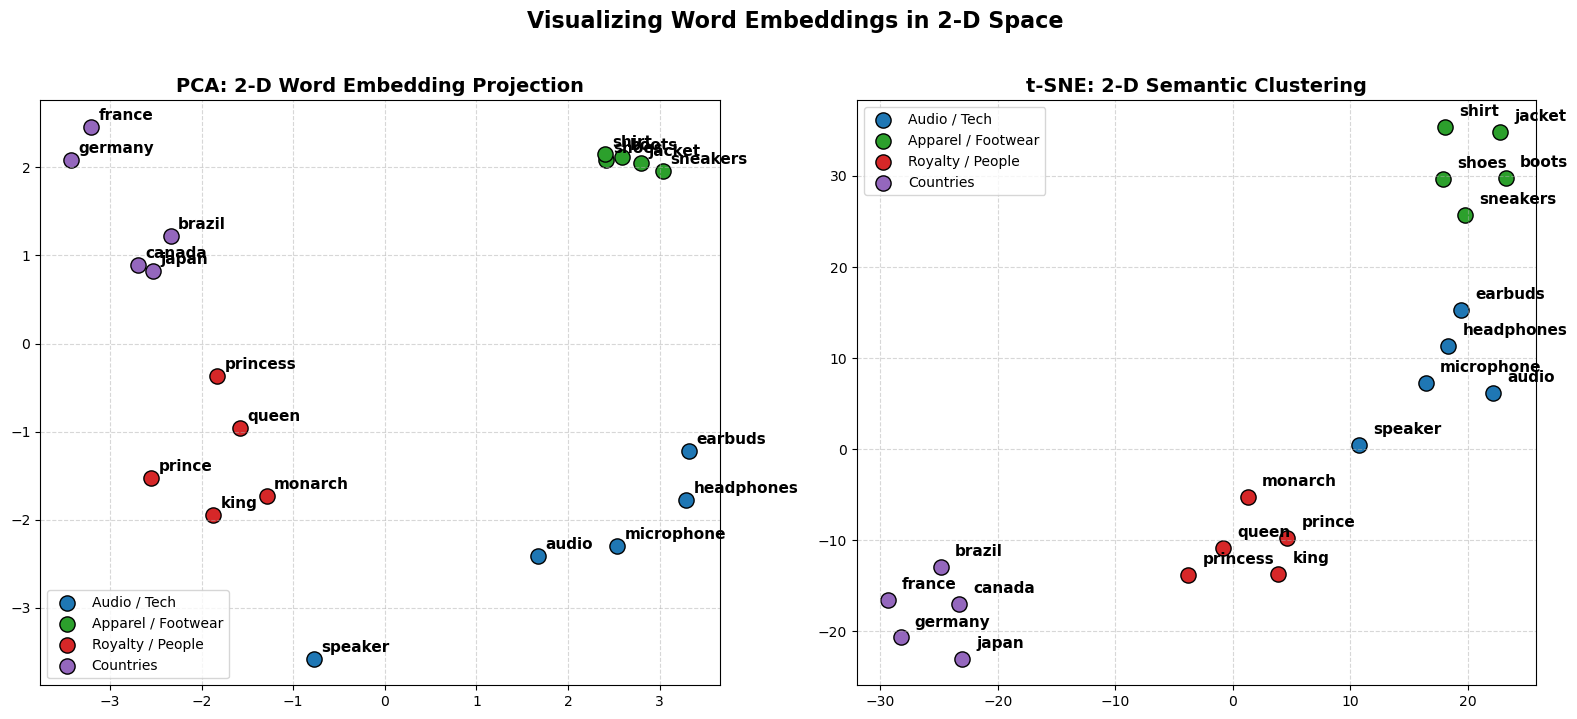

In [7]:
# Select semantic clusters of words from GloVe
word_clusters = {
    "Audio / Tech": ["headphones", "earbuds", "speaker", "audio", "microphone"],
    "Apparel / Footwear": ["shoes", "sneakers", "boots", "jacket", "shirt"],
    "Royalty / People": ["king", "queen", "prince", "princess", "monarch"],
    "Countries": ["france", "japan", "germany", "canada", "brazil"]
}

words_to_plot = []
cluster_labels = []
for category, words in word_clusters.items():
    for w in words:
        if w in glove_model:
            words_to_plot.append(w)
            cluster_labels.append(category)

# Retrieve GloVe vectors
vectors = np.array([glove_model[w] for w in words_to_plot])

# 1. PCA Reduction to 2D
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(vectors)

# 2. t-SNE Reduction to 2D
# 2. t-SNE Reduction to 2D (compatible across scikit-learn versions)
tsne_kwargs = {'n_components': 2, 'perplexity': 5, 'random_state': 42}
try:
    tsne = TSNE(**tsne_kwargs, max_iter=1000)
except TypeError:
    tsne = TSNE(**tsne_kwargs, n_iter=1000)
tsne_coords = tsne.fit_transform(vectors)

# Plotting Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
unique_cats = list(word_clusters.keys())
cat_colors = {'Audio / Tech': '#1f77b4', 'Apparel / Footwear': '#2ca02c', 'Royalty / People': '#d62728', 'Countries': '#9467bd'}

# PCA Subplot
for cat in unique_cats:
    idx = [i for i, c in enumerate(cluster_labels) if c == cat]
    axes[0].scatter(pca_coords[idx, 0], pca_coords[idx, 1], label=cat, color=cat_colors[cat], s=120, edgecolors='black')
for i, txt in enumerate(words_to_plot):
    axes[0].annotate(txt, (pca_coords[i, 0] + 0.08, pca_coords[i, 1] + 0.08), fontsize=11, fontweight='semibold')
axes[0].set_title("PCA: 2-D Word Embedding Projection", fontsize=14, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# t-SNE Subplot
for cat in unique_cats:
    idx = [i for i, c in enumerate(cluster_labels) if c == cat]
    axes[1].scatter(tsne_coords[idx, 0], tsne_coords[idx, 1], label=cat, color=cat_colors[cat], s=120, edgecolors='black')
for i, txt in enumerate(words_to_plot):
    axes[1].annotate(txt, (tsne_coords[i, 0] + 1.2, tsne_coords[i, 1] + 1.2), fontsize=11, fontweight='semibold')
axes[1].set_title("t-SNE: 2-D Semantic Clustering", fontsize=14, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle("Visualizing Word Embeddings in 2-D Space", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Real-World Exemplar: E-Commerce Semantic Product Recommendation Engine

### Problem Statement:
Traditional keyword search fails when a customer types *"running sneakers"* and the product title only contains *"athletic trainers"*, or searches for *"sound gear for workouts"* and the catalog lists *"sweat resistant earbuds"*.

Using our trained Word2Vec embeddings:
1. We compute a **document embedding vector** for each catalog item by averaging (mean-pooling) its constituent word vectors:
   $$\mathbf{d} = \frac{1}{|D|} \sum_{w \in D} \mathbf{v}_w$$
2. Given any natural language user search query, we compute its query embedding vector $\mathbf{q}$.
3. We calculate Cosine Similarity between $\mathbf{q}$ and all product vectors $\mathbf{d}_i$, returning the Top-$K$ most semantically relevant products.


In [8]:
# Product Catalog Database
product_catalog = [
    {"id": "PROD_01", "category": "Audio", "title": "AeroBeats Wireless Bluetooth Headphones Active Noise Cancellation"},
    {"id": "PROD_02", "category": "Audio", "title": "PulsePod True Wireless Stereo Earbuds with Sweat Resistance for Running"},
    {"id": "PROD_03", "category": "Footwear", "title": "Nike Air Zoom Athletic Running Sneakers with Responsive Foam Midsole"},
    {"id": "PROD_04", "category": "Footwear", "title": "UltraGlide Breathable Crossfit Shoes with Durable Rubber Traction"},
    {"id": "PROD_05", "category": "Computing", "title": "Razer Mechanical Gaming Keyboard with RGB Switches"},
    {"id": "PROD_06", "category": "Computing", "title": "Logitech Ergonomic Optical Gaming Mouse High DPI"},
    {"id": "PROD_07", "category": "Wearables", "title": "Apple Watch Smartwatch Fitness Tracker Heart Rate GPS"},
    {"id": "PROD_08", "category": "Audio", "title": "JBL Portable Outdoor Bluetooth Speaker Waterproof Bass"}
]

df_catalog = pd.DataFrame(product_catalog)
df_catalog


,id,category,title
0,PROD_01,Audio,AeroBeats Wireless Bluetooth Headphones Active...
1,PROD_02,Audio,PulsePod True Wireless Stereo Earbuds with Swe...
2,PROD_03,Footwear,Nike Air Zoom Athletic Running Sneakers with R...
3,PROD_04,Footwear,UltraGlide Breathable Crossfit Shoes with Dura...
4,PROD_05,Computing,Razer Mechanical Gaming Keyboard with RGB Swit...
5,PROD_06,Computing,Logitech Ergonomic Optical Gaming Mouse High DPI
6,PROD_07,Wearables,Apple Watch Smartwatch Fitness Tracker Heart R...
7,PROD_08,Audio,JBL Portable Outdoor Bluetooth Speaker Waterpr...


### Implementing the Semantic Recommendation Engine

In [9]:
class SemanticProductRecommender:
    """Recommends products based on semantic similarity of word embedding averages."""
    def __init__(self, embedding_model, catalog_df):
        self.model = embedding_model
        self.catalog = catalog_df.copy()
        self.product_vectors = []
        
        # Precompute document vectors for all catalog items
        for title in self.catalog['title']:
            vec = self._vectorize_text(title)
            self.product_vectors.append(vec)
        self.product_vectors = np.array(self.product_vectors)

    def _vectorize_text(self, text):
        """Computes mean word embedding vector for a sentence."""
        tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())
        word_vecs = [self.model[w] for w in tokens if w in self.model]
        if not word_vecs:
            # Fallback zero vector
            return np.zeros(self.model.vector_size)
        return np.mean(word_vecs, axis=0)

    def recommend(self, query, top_k=3):
        """Retrieves top_k products matching semantic intent of user query."""
        query_vec = self._vectorize_text(query).reshape(1, -1)
        sim_scores = cosine_similarity(query_vec, self.product_vectors).flatten()
        
        # Rank by highest similarity
        ranked_indices = np.argsort(sim_scores)[::-1][:top_k]
        
        recommendations = []
        for rank, idx in enumerate(ranked_indices, 1):
            item = self.catalog.iloc[idx].to_dict()
            item['similarity_score'] = round(float(sim_scores[idx]), 4)
            item['rank'] = rank
            recommendations.append(item)
            
        return pd.DataFrame(recommendations)[['rank', 'id', 'category', 'title', 'similarity_score']]

# Initialize recommender using our pre-trained GloVe model (broad vocabulary coverage)
recommender = SemanticProductRecommender(glove_model, df_catalog)
print("Semantic Product Recommender initialized successfully!")


Semantic Product Recommender initialized successfully!


### Testing Real-World E-Commerce Customer Search Queries
Notice how queries match relevant products even without exact keyword overlap:


In [10]:
test_queries = [
    "wireless sound gear for marathon running",
    "cushioned athletic trainers for jogging",
    "computer hardware gaming accessories"
]

for q in test_queries:
    print("=" * 80)
    print(f"SEARCH QUERY: '{q}'")
    print("=" * 80)
    recs = recommender.recommend(q, top_k=3)
    print(recs.to_string(index=False))
    print()


SEARCH QUERY: 'wireless sound gear for marathon running'
 rank      id  category                                                                   title  similarity_score
    1 PROD_02     Audio PulsePod True Wireless Stereo Earbuds with Sweat Resistance for Running            0.8925
    2 PROD_07 Wearables                   Apple Watch Smartwatch Fitness Tracker Heart Rate GPS            0.8202
    3 PROD_03  Footwear    Nike Air Zoom Athletic Running Sneakers with Responsive Foam Midsole            0.7846

SEARCH QUERY: 'cushioned athletic trainers for jogging'
 rank      id category                                                                   title  similarity_score
    1 PROD_03 Footwear    Nike Air Zoom Athletic Running Sneakers with Responsive Foam Midsole            0.7829
    2 PROD_02    Audio PulsePod True Wireless Stereo Earbuds with Sweat Resistance for Running            0.6572
    3 PROD_04 Footwear       UltraGlide Breathable Crossfit Shoes with Durable Rubber Tract

## 7. Conclusion & Key Takeaways

1. **Dense Representations:** Unlike sparse, high-dimensional BoW/TF-IDF representations, Word2Vec and GloVe map words into compact, continuous vector spaces (e.g., 50 to 300 dimensions) capturing latent semantics.
2. **Linear Substructures & Analogies:** Dense embeddings preserve relational semantic directions, demonstrated by vector algebra $\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} \approx \mathbf{v}_{\text{queen}}$.
3. **Dimensionality Reduction:** Both PCA and t-SNE demonstrate that words belonging to coherent ontological domains (Audio, Footwear, Royalty, Geography) form distinct, tight clusters in 2-D space.
4. **Semantic Recommendations:** Aggregating word embeddings enables e-commerce search engines to overcome vocabulary mismatch and suggest contextually relevant products for customer queries.
